In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv("D:\Semester-5\Machine Learning - Lab\Assignment-2\dataset\spambase_csv.csv")

df.head()

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\sathi\AppData\Local\Temp\ipykernel_29252\3110234905.py:1: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv("D:\Semester-5\Machine Learning - Lab\Assignment-2\dataset\spambase_csv.csv")


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (4601, 58)


In [5]:
df.isnull().sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 391


In [8]:
df = df.drop_duplicates()

In [9]:
print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (4210, 58)


In [10]:
df.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,...,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000,4210.000000
mean,0.104366,0.112656,0.291473,0.063078,0.325321,0.096656,0.117475,0.108000,0.091860,0.248420,...,0.040403,0.144048,0.017376,0.281136,0.076057,0.045798,5.383896,52.139905,291.181948,0.398812
std,0.300005,0.454260,0.515719,1.352487,0.687805,0.276030,0.397284,0.410282,0.282144,0.656638,...,0.252533,0.274256,0.105731,0.843321,0.239708,0.435925,33.147358,199.582168,618.654838,0.489712
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.627500,7.000000,40.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.073000,0.000000,0.016000,0.000000,0.000000,2.297000,15.000000,101.500000,0.000000
75%,0.000000,0.000000,0.440000,0.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.190000,...,0.000000,0.194000,0.000000,0.331000,0.053000,0.000000,3.706750,44.000000,273.750000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [11]:
print(df["class"].value_counts())

class
0    2531
1    1679
Name: count, dtype: int64


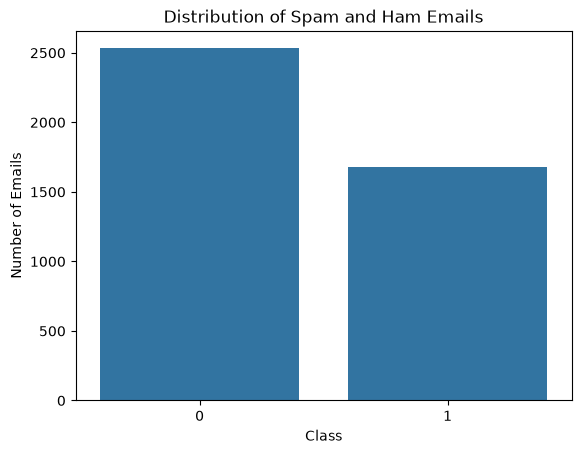

In [12]:
sns.countplot(data=df, x="class")

plt.title("Distribution of Spam and Ham Emails")
plt.xlabel("Class")
plt.ylabel("Number of Emails")

plt.show()

In [13]:
X = df.drop("class", axis=1)

y = df["class"]

In [14]:
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (4210, 57)
Target Shape: (4210,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
baseline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

In [19]:
start_time = time.time()

baseline_lr.fit(X_train, y_train)

lr_training_time = time.time() - start_time

print("Training Time:", lr_training_time)

Training Time: 0.06647205352783203


In [20]:
y_pred_baseline_lr = baseline_lr.predict(X_test)

In [21]:
lr_accuracy = accuracy_score(y_test, y_pred_baseline_lr)

lr_precision = precision_score(y_test, y_pred_baseline_lr)

lr_recall = recall_score(y_test, y_pred_baseline_lr)

lr_f1 = f1_score(y_test, y_pred_baseline_lr)

print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)

Accuracy: 0.9346793349168646
Precision: 0.9296636085626911
Recall: 0.9047619047619048
F1 Score: 0.9170437405731523


In [22]:
print(classification_report(y_test, y_pred_baseline_lr))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95       506
           1       0.93      0.90      0.92       336

    accuracy                           0.93       842
   macro avg       0.93      0.93      0.93       842
weighted avg       0.93      0.93      0.93       842



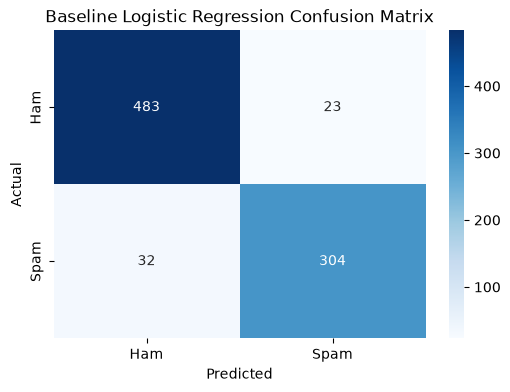

In [23]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_baseline_lr
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Baseline Logistic Regression Confusion Matrix")

plt.show()

In [24]:
param_grid_lr = {
    "model__penalty": ["l1", "l2"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "saga"]
}

In [28]:
grid_lr = GridSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            random_state=42
        ))
    ]),
    param_grid=param_grid_lr,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

In [29]:
start_time = time.time()

grid_lr.fit(X_train, y_train)

lr_tuning_time = time.time() - start_time

print("Best Parameters:")
print(grid_lr.best_params_)

print("\nBest CV Accuracy:")
print(grid_lr.best_score_)

print("\nTuning Time:")
print(lr_tuning_time)

c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Parameters:
{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Best CV Accuracy:
0.9233993677276555

Tuning Time:
32.52289414405823


In [30]:
best_lr = grid_lr.best_estimator_

best_lr

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['word_freq_make','word_freq_address','word_freq_all',..., 'capital_run_length_average','capital_run_length_longest', 'capital_run_length_total']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [31]:
y_pred_best_lr = best_lr.predict(X_test)

best_lr_accuracy = accuracy_score(
    y_test,
    y_pred_best_lr
)

best_lr_precision = precision_score(
    y_test,
    y_pred_best_lr
)

best_lr_recall = recall_score(
    y_test,
    y_pred_best_lr
)

best_lr_f1 = f1_score(
    y_test,
    y_pred_best_lr
)

print("Accuracy:", best_lr_accuracy)
print("Precision:", best_lr_precision)
print("Recall:", best_lr_recall)
print("F1 Score:", best_lr_f1)

Accuracy: 0.9406175771971497
Precision: 0.9359756097560976
Recall: 0.9136904761904762
F1 Score: 0.9246987951807228


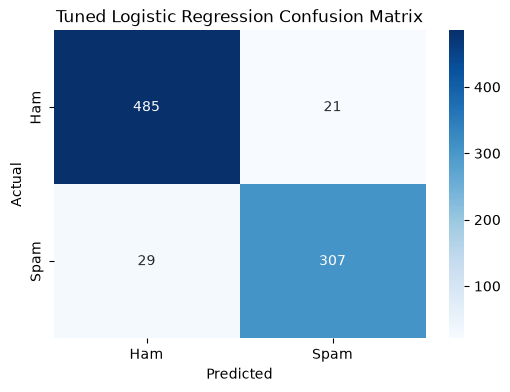

In [33]:
cm_best_lr = confusion_matrix(
    y_test,
    y_pred_best_lr
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_best_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Tuned Logistic Regression Confusion Matrix")

plt.show()

In [34]:
kernels = ["linear", "poly", "rbf", "sigmoid"]

In [35]:
svm_results = []

for kernel in kernels:

    svm = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel=kernel,
            random_state=42
        ))
    ])

    start_time = time.time()

    svm.fit(X_train, y_train)

    training_time = time.time() - start_time

    y_pred = svm.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    svm_results.append({
        "Kernel": kernel,
        "Accuracy": accuracy,
        "F1 Score": f1,
        "Training Time (s)": training_time
    })

In [36]:
svm_results_df = pd.DataFrame(svm_results)

svm_results_df

,Kernel,Accuracy,F1 Score,Training Time (s)
0,linear,0.935867,0.918919,0.425602
1,poly,0.766033,0.598778,0.358391
2,rbf,0.932304,0.913505,0.168977
3,sigmoid,0.896675,0.867580,0.196202


In [37]:
param_grid_svm = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 100]
    },
    
    {
        "model__kernel": ["poly"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto"],
        "model__degree": [2, 3, 4]
    },
    
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto"]
    },
    
    {
        "model__kernel": ["sigmoid"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto"]
    }
]

In [38]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

In [39]:
grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

In [40]:
start_time = time.time()

grid_svm.fit(X_train, y_train)

svm_tuning_time = time.time() - start_time

print("Best Parameters:")
print(grid_svm.best_params_)

print("\nBest CV Accuracy:")
print(grid_svm.best_score_)

print("\nTuning Time:")
print(svm_tuning_time)

Best Parameters:
{'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

Best CV Accuracy:
0.9284509327560284

Tuning Time:
52.441240549087524


In [41]:
best_svm = grid_svm.best_estimator_

best_svm

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](57,)","['word_freq_make','word_freq_address','word_freq_all',..., 'capital_run_length_average','capital_run_length_longest', 'capital_run_length_total']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,57
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [43]:
y_pred_best_svm = best_svm.predict(X_test)

best_svm_accuracy = accuracy_score(
    y_test,
    y_pred_best_svm
)

best_svm_precision = precision_score(
    y_test,
    y_pred_best_svm
)

best_svm_recall = recall_score(
    y_test,
    y_pred_best_svm
)

best_svm_f1 = f1_score(
    y_test,
    y_pred_best_svm
)

print("Accuracy:", best_svm_accuracy)
print("Precision:", best_svm_precision)
print("Recall:", best_svm_recall)
print("F1 Score:", best_svm_f1)

Accuracy: 0.9334916864608076
Precision: 0.9294478527607362
Recall: 0.9017857142857143
F1 Score: 0.9154078549848943


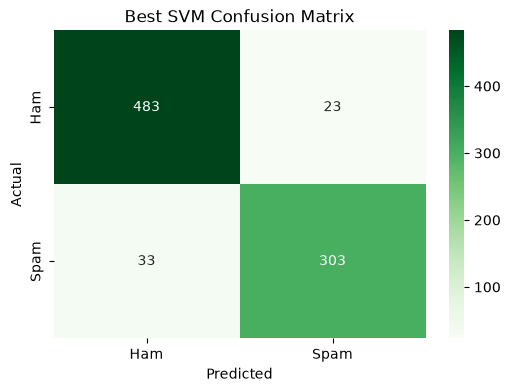

In [44]:
cm_best_svm = confusion_matrix(
    y_test,
    y_pred_best_svm
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_best_svm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Best SVM Confusion Matrix")

plt.show()

In [45]:
lr_cv_scores = cross_val_score(
    best_lr,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

for i, score in enumerate(lr_cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nAverage CV Accuracy: {lr_cv_scores.mean():.4f}")

Fold 1: 0.9139
Fold 2: 0.9318
Fold 3: 0.9154
Fold 4: 0.9198
Fold 5: 0.9361

Average CV Accuracy: 0.9234


In [46]:
svm_cv_scores = cross_val_score(
    best_svm,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

for i, score in enumerate(svm_cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nAverage CV Accuracy: {svm_cv_scores.mean():.4f}")

Fold 1: 0.9214
Fold 2: 0.9436
Fold 3: 0.8976
Fold 4: 0.9406
Fold 5: 0.9391

Average CV Accuracy: 0.9285


In [47]:
cv_results = pd.DataFrame({
    "Fold": [
        "Fold 1",
        "Fold 2",
        "Fold 3",
        "Fold 4",
        "Fold 5"
    ],
    
    "Logistic Regression": lr_cv_scores,
    
    "SVM": svm_cv_scores
})

cv_results.loc[len(cv_results)] = [
    "Average",
    lr_cv_scores.mean(),
    svm_cv_scores.mean()
]

cv_results

,Fold,Logistic Regression,SVM
0,Fold 1,0.913947,0.921365
1,Fold 2,0.931751,0.943620
2,Fold 3,0.915430,0.897626
3,Fold 4,0.919762,0.940565
4,Fold 5,0.936107,0.939079
5,Average,0.923399,0.928451


In [48]:
lr_performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (s)"
    ],
    
    "Value": [
        best_lr_accuracy,
        best_lr_precision,
        best_lr_recall,
        best_lr_f1,
        lr_training_time
    ]
})

lr_performance

,Metric,Value
0,Accuracy,0.940618
1,Precision,0.935976
2,Recall,0.913690
3,F1 Score,0.924699
4,Training Time (s),0.066472


In [49]:
tuning_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM"
    ],
    
    "Search Method": [
        "Grid Search",
        "Grid Search"
    ],
    
    "Best Parameters": [
        str(grid_lr.best_params_),
        str(grid_svm.best_params_)
    ],
    
    "Best CV Accuracy": [
        grid_lr.best_score_,
        grid_svm.best_score_
    ]
})

tuning_results

,Model,Search Method,Best Parameters,Best CV Accuracy
0,Logistic Regression,Grid Search,"{'model__C': 10, 'model__penalty': 'l2', 'mode...",0.923399
1,SVM,Grid Search,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",0.928451


In [51]:
final_comparison = pd.DataFrame({
    "Criterion": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Model Complexity",
        "Interpretability"
    ],
    
    "Logistic Regression": [
        best_lr_accuracy,
        best_lr_precision,
        best_lr_recall,
        best_lr_f1,
        "Low",
        "High"
    ],
    
    "SVM": [
        best_svm_accuracy,
        best_svm_precision,
        best_svm_recall,
        best_svm_f1,
        "High",
        "Low"
    ]
})

final_comparison

,Criterion,Logistic Regression,SVM
0,Accuracy,0.940618,0.933492
1,Precision,0.935976,0.929448
2,Recall,0.91369,0.901786
3,F1 Score,0.924699,0.915408
4,Model Complexity,Low,High
5,Interpretability,High,Low
